# Quantization Basics

In this notebook we will explore the fundamentals of quantization using one of the layers of a pre-trained model.

## Recommended Hardware

This notebook can run on the following hardware or remote resources.

✅ AMD EPYC™ Processors  
✅ AMD Ryzen™ (AI) Processors  

[![Open in AMD Developer Cloud](https://img.shields.io/badge/Open_in_AMD_Developer_Cloud-000000?logo=amd&logoSize=auto)](https://amd-ai-academy.com/github/AMDResearch/aup-ai-tutorials/blob/main/quant/01.quant_basics.ipynb)  

A GPU in not needed for this notebook.

## Software Environment

Install ROCm on your system.

| Linux | Windows |
|-------|---------|
| [Install PyTorch](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/install/quick-start.html) | [PyTorch on Windows](https://rocm.docs.amd.com/projects/radeon-ryzen/en/latest/docs/install/installrad/windows/install-pytorch.html)|
| [Install Docker container](https://amdresearch.github.io/aup-ai-tutorials//env/env-gpu.html) | |

## Goals

- Explore symmetric and asymmetric quantization
- Visualize value distribution

## Install Dependencies

Install the package dependencies needed for this notebook or series of notebooks.

First, get the `aup_config.py` script locally if needed. Then install the dependencies (`aup_setup()`). This step may take a few minutes and only needs to be done once.

In [ ]:
![ -f aup_config.py ] || wget https://raw.githubusercontent.com/AMDResearch/aup-ai-tutorials/refs/heads/main/quant/aup_config.py

In [ ]:
from aup_config import aup_setup
aup_setup()

## Explore Quantization

### Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models.resnet as resnet
from ml_dtypes import bfloat16

### Get Resnet50

We are going to use the fully connected layer of a pre-trained Resnet50 model to learn about the basics of quantization.

Let us download the pre-trained ResNet50 and check the weights of the fully connected layer. As you will see there are over 2 million parameters, which is great to use as starting point.

In [2]:
resnet50 = resnet.resnet50(weights=resnet.ResNet50_Weights.DEFAULT)

In [3]:
resnet50.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [4]:
resnet50.fc.weight.data

tensor([[ 0.0112,  0.0344, -0.0253,  ..., -0.0133, -0.0042,  0.0459],
        [ 0.0012,  0.0682, -0.0034,  ...,  0.0106, -0.0296,  0.0129],
        [ 0.0359, -0.0144,  0.0174,  ..., -0.0017, -0.0061,  0.0116],
        ...,
        [-0.0177,  0.1227,  0.0103,  ...,  0.0024,  0.0251, -0.0006],
        [ 0.0595, -0.1045,  0.0044,  ..., -0.0066, -0.0409, -0.0277],
        [ 0.0259,  0.0079, -0.0239,  ..., -0.0411, -0.0117,  0.0102]])

In [5]:
print(f'Number of weights of the fully connected layer {resnet50.fc.weight.numel():,} '
      f'of type {resnet50.fc.weight.data.dtype}. '
      f'Total bytes {resnet50.fc.weight.data.itemsize * resnet50.fc.weight.numel() / 1024 / 1024} MB.')

Number of weights of the fully connected layer 2,048,000 of type torch.float32. Total bytes 7.8125 MB.


### Fully Connect Layer Parameters Distribution

Now, for a better understanding of the weights we will visualize their distribution on a histogram.

In [6]:
fc_weights = resnet50.fc.weight.data.numpy()
fc_weights_flat = fc_weights.flatten()

We are going to define a function to help us plot the histogram and cumulative distribution of the weights.

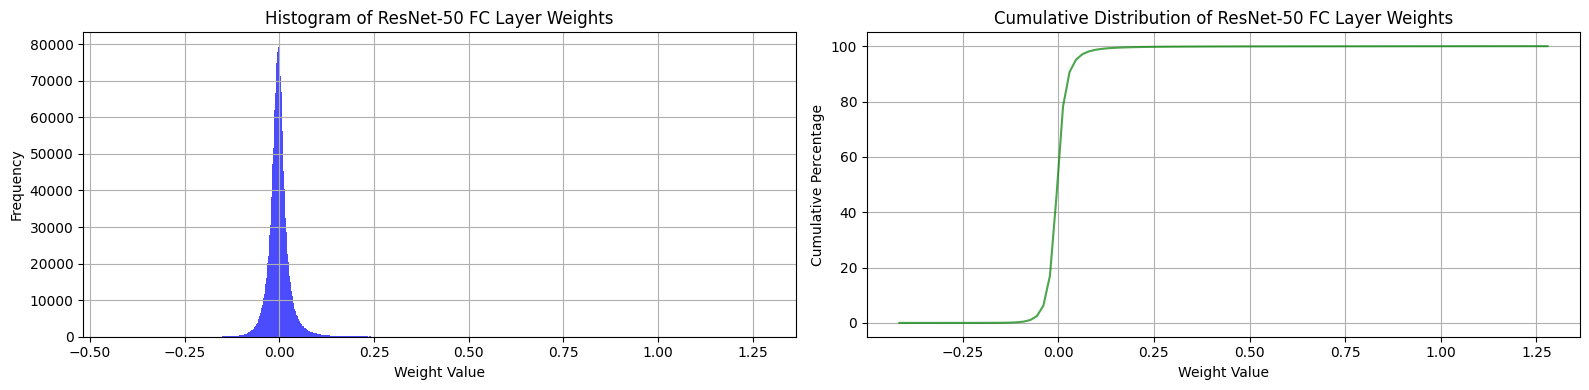

In [ ]:
def plot_weights_distribution(weights, compute_range=False):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

    num_bins = 1000
    if compute_range:
        num_bins = int(np.max(weights)) - int(np.min(weights))

    # Histogram plot
    axes[0].hist(weights, bins=num_bins, color='b', alpha=0.7)
    axes[0].set_title("Histogram of ResNet-50 FC Layer Weights")
    axes[0].set_xlabel("Weight Value")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)

    # Compute cumulative histogram and normalize it to 100%
    count, bins = np.histogram(weights, bins=100)
    cumulative = np.cumsum(count)
    cumulative_normalized = (cumulative / cumulative[-1]) * 100

    # Plot cumulative distribution
    axes[1].plot(bins[1:], cumulative_normalized, color='g', alpha=0.7)
    axes[1].set_title("Cumulative Distribution of ResNet-50 FC Layer Weights")
    axes[1].set_xlabel("Weight Value")
    axes[1].set_ylabel("Cumulative Percentage")
    axes[1].grid(True)

    # Show the plots
    plt.tight_layout()
    plt.show()

plot_weights_distribution(fc_weights_flat)

As you can see most of the wights are centered around 0 and concentrated in a very narrow range from approximately -0.13 to 0.13. Although, there are values outside this range.

In [8]:
print(f'Weight values range from {np.min(fc_weights):.3f} '
      f'to {np.max(fc_weights):.3f}. Total range {np.max(fc_weights)-np.min(fc_weights):.3f}')

Weight values range from -0.432 to 1.279. Total range 1.711


We can zoom in the distribution of the values that are not part of the main contribution. We will set a positive an negative threshold. You can explore different values.

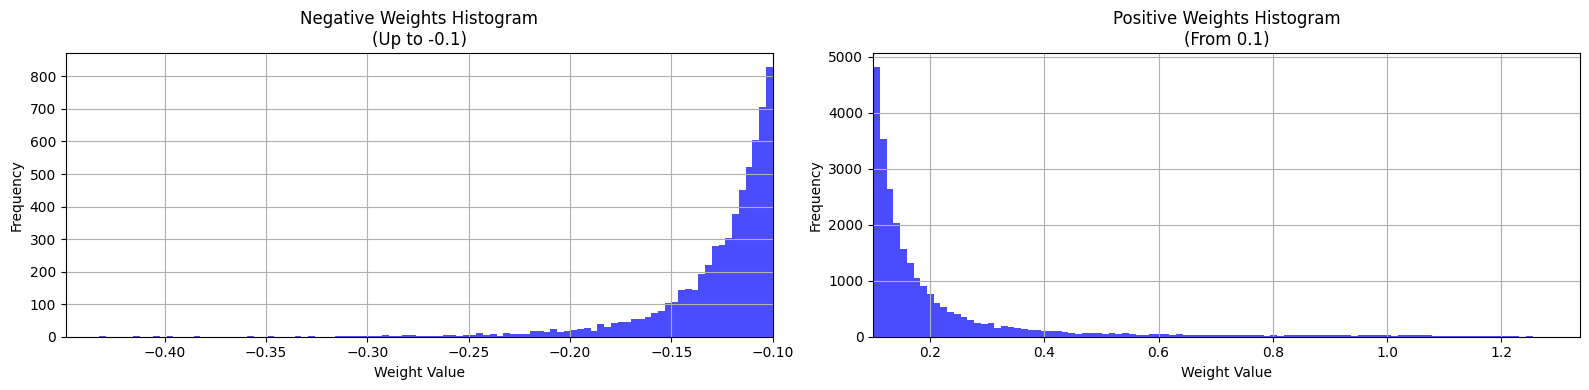

In [9]:
# Define the thresholds
negative_threshold = -0.10
positive_threshold = negative_threshold * -1

# Filter weights for negative and positive sides
negative_weights = fc_weights_flat[fc_weights_flat <= negative_threshold]
positive_weights = fc_weights_flat[fc_weights_flat >= positive_threshold]

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# Negative side histogram
axes[0].hist(negative_weights, bins=100, color='b', alpha=0.7)
axes[0].set_title(f"Negative Weights Histogram\n(Up to {negative_threshold})")
axes[0].set_xlabel("Weight Value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)
axes[0].set_xlim(right=negative_threshold)

# Positive side histogram
axes[1].hist(positive_weights, bins=100, color='b', alpha=0.7)
axes[1].set_title(f"Positive Weights Histogram\n(From {positive_threshold})")
axes[1].set_xlabel("Weight Value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)
axes[1].set_xlim(left=positive_threshold)

# Show the plots
plt.tight_layout()
plt.show()

## Value Representation

We have seen the distribution of the weighs for the fully connected layer of the Resnet50. The way values are represented as `torch.float32` or `float32`, this is a [single precision floating point format](https://en.wikipedia.org/wiki/Single-precision_floating-point_format) also known as `float`. This format uses 32-bit to represent a number. These 32-bit are decomposed as follow
- 1 bit for the sign
- 8 bits for exponent
- 23 bits for significand precision

The range of numbers that can be represented with `float` is -3.4 x 10<sup>38</sup> to 3.4 x 10<sup>38</sup>

There are other ways of representing values, such as
- [Integers](https://en.wikipedia.org/wiki/Integer_(computer_science)): `int32`, `int16`, `int8`, `int4`
- [Fixed-point arithmetic](https://en.wikipedia.org/wiki/Fixed-point_arithmetic): Unlike float, the decimal point is always fixed. The computation is faster because there is no need to normalize.
- Floating point: [float16](https://en.wikipedia.org/wiki/Half-precision_floating-point_format), [bfloat16](https://en.wikipedia.org/wiki/Bfloat16_floating-point_format)
- [Block floating point](https://en.wikipedia.org/wiki/Block_floating_point) such as the microscaling formats

## Quantization

Quantization refers to the process of reducing the precision of a value, typically from a continuous range such as real numbers to a discrete set. The aim of quantization is to reduce the number of bits needed to represent a value saving memory as well as computation.

Typically, AI models are trained using single precision floating point format which is already a way of quantizing real numbers. However, we can still do further quantization, i.e., take `float` values and quantize them to other representations that use less bits, this typically incur in memory savings at the expense of numerical errors. In the following sections, we will explore different ways of quantizing values and the associated error.

### Symmetric Quantization

We are going to quantize the `float32` values to `int8`. `int8` range is between -128 to 127 and uses 8 bits. This is 4 times less bits than `float32`.

First, we are going to define a metric to measure the quantization error. We will use the [mean squared error](https://en.wikipedia.org/wiki/Mean_squared_error) (MSE) and [residual sum of squares](https://en.wikipedia.org/wiki/Residual_sum_of_squares) (RSS).

In [10]:
def quantization_error_stats(actual, quantized) -> tuple[float, float]:
    """Compute Mean Squared Error and Residual Sum of Squares Errors"""
    squared_diffs = (actual - quantized) ** 2
    mse = np.mean(squared_diffs)
    rss = np.sum(squared_diffs)
    return mse, rss

To start with the quantization, we need to find the absolute maximum value, either in the negative or positive side.

In [11]:
max_value = np.max(np.abs(fc_weights_flat))
print(f'{max_value=}')

max_value=np.float32(1.2790387)


An `int8` format, can represent numbers between -128 to 127, note that it is not a symmetric range. We will use `max_value` to find the scale factor to bring the samples from the `float` representation to the `int8` representation. We compute the scale factor by dividing the absolute maximum value of the `int8` range, we will use 127 to make the mapping symmetric, by `max_value` from the original samples. 

The scale factor is

In [12]:
scale_sym_int8 = (np.iinfo(np.int8).max - 1) / max_value
print(f'{scale_sym_int8=}')

scale_sym_int8=np.float32(98.51149)


Multiplying `scale_sym_int8` by the original samples brings us one step closer to `int8`. However, these values still have a fractional part. Additionally, we have not lost any information. This operation is reversible.   

In [13]:
fc_weights_scale_sym_int8 = fc_weights_flat * scale_sym_int8

In [14]:
print(f'Weight values range from {np.min(fc_weights_scale_sym_int8):.3f} '
      f'to {np.max(fc_weights_scale_sym_int8):.3f}. '
      f'Total range {np.max(fc_weights_scale_sym_int8)-np.min(fc_weights_scale_sym_int8):.3f}')

Weight values range from -42.588 to 126.000. Total range 168.588


So far, we have only scaled the original values by `scale_sym_int8`, we have not incurred in any error, in other words we can recover the original values

In [15]:
print(f'Are array equal? {np.array_equal(fc_weights_flat * scale_sym_int8, fc_weights_scale_sym_int8)}')

Are array equal? True


To actually quantize, we need to round the number to the nearest integer. By doing this we have lost information and we are no longer able to recover the original values.

The additional casting below is conceptually not necessary, but practically we need it if we want to reduce the amount of memory used.

In [16]:
fc_weights_round_int8 = np.int8(np.rint(fc_weights_scale_sym_int8))

If we now compare the original and quantized values, you will see that the arrays are no longer equal. Thus, lost of precision which will reflect in lost accuracy.

In [17]:
print(f'Are array equal? {np.array_equal(fc_weights_flat * scale_sym_int8, fc_weights_round_int8)}')

Are array equal? False


We can now compute the MSE for this quantization.

In [18]:
int8_sym_mse, int8_sym_rss = quantization_error_stats(fc_weights_flat, fc_weights_round_int8/scale_sym_int8)
print(f'Symmetric INT8 Quant MSE: {int8_sym_mse}, RSS: {int8_sym_rss}')

Symmetric INT8 Quant MSE: 8.586763215134852e-06, RSS: 17.585691452026367


Let plot the distribution again, note how the X axis is integer values. The histogram is no longer smooth as it is quantized.

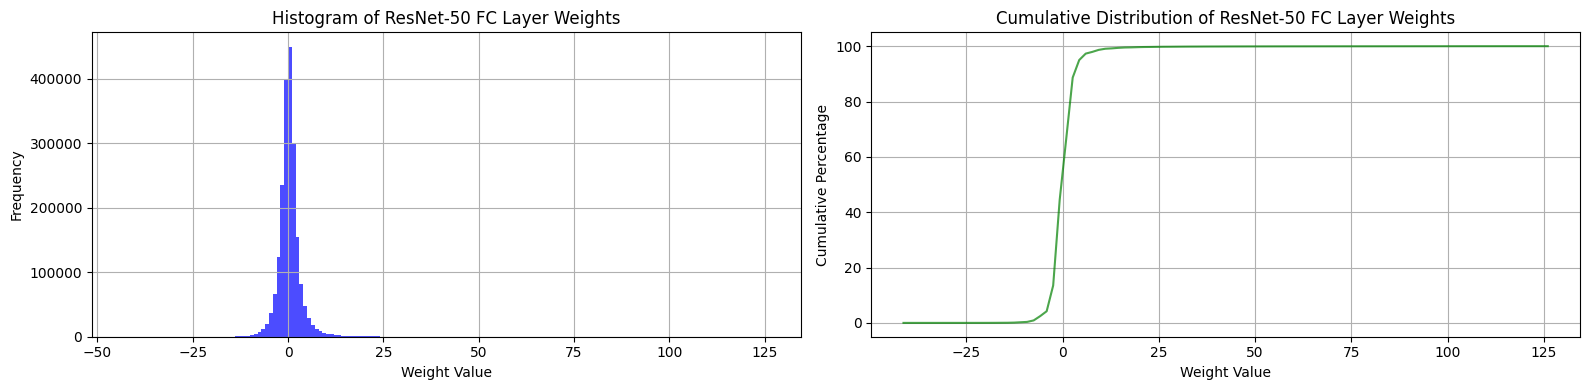

In [19]:
plot_weights_distribution(fc_weights_round_int8, True)

Finally, we can explore the quantization error. For this, we take the original weights and subtract the descaled quantized weights.

In [ ]:
fc_weights_error_int8 = fc_weights_flat - fc_weights_round_int8 / scale_sym_int8

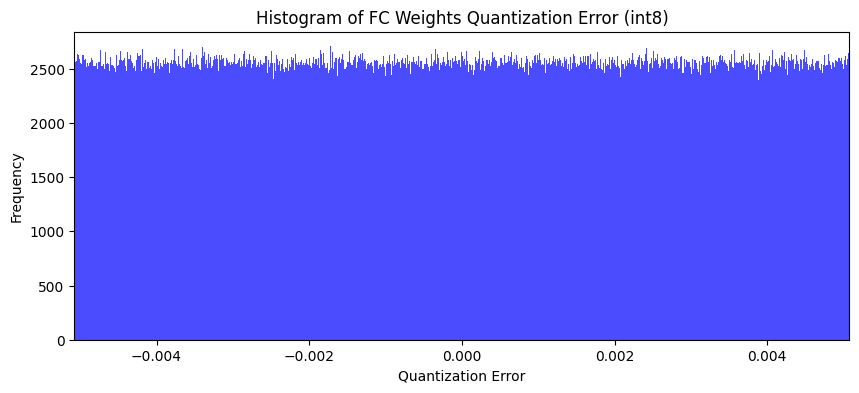

In [21]:
def plot_quant_error(weights_quant, type_name):
    plt.figure(figsize=(10, 4))
    plt.hist(weights_quant, bins=800, color='b', alpha=0.7)
    plt.title(f"Histogram of FC Weights Quantization Error ({type_name})")
    plt.xlabel("Quantization Error")
    plt.ylabel("Frequency")
    plt.xlim([np.min(weights_quant), np.max(weights_quant)])
    plt.show()

plot_quant_error(fc_weights_error_int8, str(fc_weights_round_int8.dtype))

You can see the (almost) uniform distribution of the quantization error. Because we are dealing with integers the error will always be slightly less than &plusmn; 0.5, in the quantized space.

In [22]:
print(f'Minimum error {np.min(fc_weights_error_int8):} {np.max(fc_weights_error_int8):}')
print(f'Minimum error scaled {np.min(fc_weights_error_int8*scale_sym_int8):} {np.max(fc_weights_error_int8*scale_sym_int8):}')

Minimum error -0.005075547844171524 0.005075541790574789
Minimum error scaled -0.4999997913837433 0.49999919533729553


### Quantize with bfloat16

We did the process of quantizing to `int8`. Quantizing to other float format such as `bfloat16` is easier. With NumPy we can do this, by just casting.

In [23]:
fc_weights_round_bfloat16 = bfloat16(fc_weights_flat)

We can compute the quantization error and check if the arrays are equal

In [24]:
print(f'Are array equal? {np.array_equal(fc_weights_flat, fc_weights_round_bfloat16)}')

Are array equal? False


In [25]:
fc_weights_error_bfloat16 = fc_weights_flat - fc_weights_round_bfloat16
print(f'Minimum error {np.min(fc_weights_error_bfloat16):} {np.max(fc_weights_error_bfloat16):}')

Minimum error -0.003885507583618164 0.0038902759552001953


By plotting the quantization error we can see that the error is mostly centered around zero. 

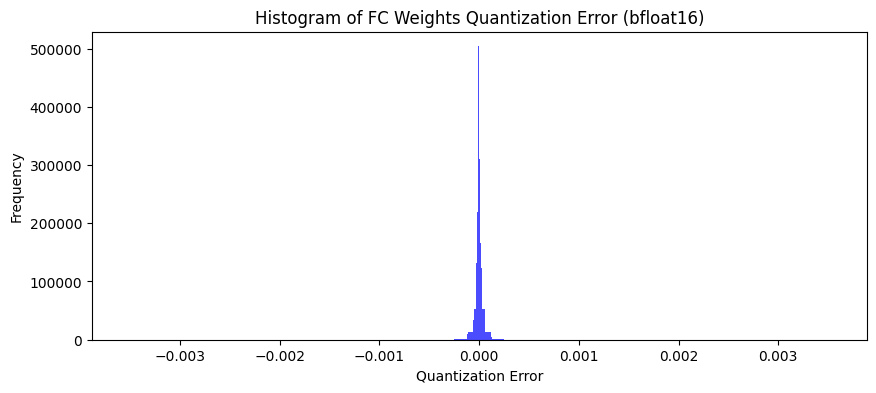

In [26]:
plot_quant_error(fc_weights_error_bfloat16, str(fc_weights_round_bfloat16.dtype))

The MSE is lower than `int8` as well as the RSS.

In [27]:
bf16_sym_mse, bf16_sym_rss = quantization_error_stats(fc_weights_flat, fc_weights_round_bfloat16)
print(f'Symmetric Bfloat16 Quant MSE: {bf16_sym_mse}, RSS: {bf16_sym_rss}')

Symmetric Bfloat16 Quant MSE: 4.535250397452728e-09, RSS: 0.009288192726671696


### Asymmetric Quantization

So far, we have done symmetric quantization where the zero point of the original weights are mapped to the 0 of the quantized range. In asymmetric quantization, the zero point does not land in 0 of the quantized range.

We start by finding the scale factor using the range of the datatype we are using to quantize, which for `int8` is 255. Then we divide this by the difference of the maximum and minimum value of the original weights. Note how this value is slightly higher than symmetric quantization. 

In [28]:
scale_asym_int8 = (np.iinfo(np.int8).max - np.iinfo(np.int8).min) / (np.max(fc_weights_flat) - np.min(fc_weights_flat))
print(f'{scale_asym_int8=}')

scale_asym_int8=np.float32(149.00497)


Then, we need to find out where the zero point is going to land in the quantized range. We find the integer value of the scale factor multiplied by the minimum value of the weights. Note that we multiply by `-1` the scale before doing this. After this we subtract the most negative value we can represent in the quantized range, this is -128 for `int8`.

In [29]:
asym_zero_point = np.int8(np.rint(np.min(fc_weights_flat) * -scale_asym_int8 - np.iinfo(np.int8).min))
print(f'{asym_zero_point=}')

asym_zero_point=np.int8(-64)


To map the weights to the quantized range, we first multiply the scale factor by the original value and then we add the zero point. Finally, we round to the nearest integer.

In [30]:
fc_weights_quant_asym_int8 = np.int8(np.rint(scale_asym_int8 * fc_weights_flat + asym_zero_point))

Now, we can see the distribution. Note how the center of the bell curve now is centered around the new zero point we computed and not the actual value 0.

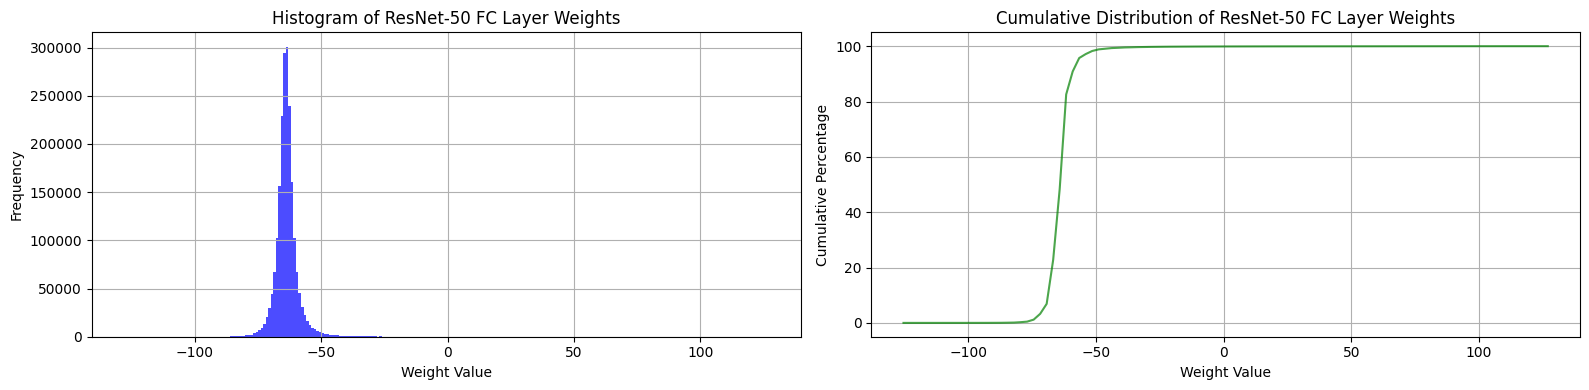

In [31]:
plot_weights_distribution(fc_weights_quant_asym_int8, True)

To compute the error, we dequantize first and then subtract from the original values.

> Note: To ensure no representation errors, we cast the quantized array to `float32`.

In [32]:
fc_weights_asym_dequantized = (fc_weights_quant_asym_int8.astype(np.float32) - asym_zero_point) / scale_asym_int8
fc_weights_asym_error_int8 = fc_weights_flat - fc_weights_asym_dequantized

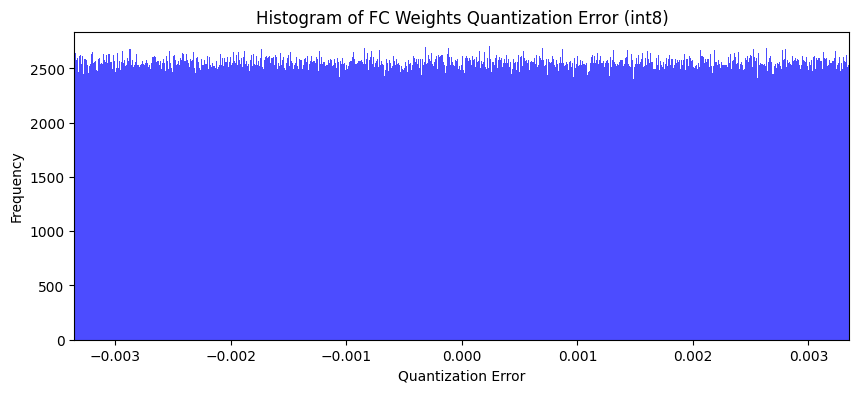

In [33]:
plot_quant_error(fc_weights_asym_error_int8, str(fc_weights_quant_asym_int8.dtype))

In [34]:
int8_asym_mse, int8_asym_rss = quantization_error_stats(fc_weights_flat, fc_weights_asym_dequantized)
print(f'Asymmetric INT8 Quant MSE: {int8_asym_mse}, RSS: {int8_asym_rss}')

Asymmetric INT8 Quant MSE: 3.754458475668798e-06, RSS: 7.689130783081055


### Clip and Quantize

We saw both symmetric and asymmetric quantization. We can also decide to clip the values, this is only to focus on a particular range of the original weights. Anything outside these values will be saturated to the maximum.

In [35]:
fc_weights_clipped = np.clip(fc_weights_flat, -0.15, 0.15)

In [ ]:
max_value_clip = np.max(np.abs(fc_weights_clipped))
print(f'{max_value_clip=}')

max_value=np.float32(0.15)


In [ ]:
scale_sym_clip_int8 = (np.iinfo(np.int8).max) / max_value_clip
print(f'{scale_sym_clip_int8=}')

scale_sym_clip_int8=np.float32(846.6666)


In [38]:
fc_weights_scale_sym_clip_int8 = fc_weights_clipped * scale_sym_clip_int8

In [39]:
print(f'Weight values range from {np.min(fc_weights_scale_sym_clip_int8):.3f} to {np.max(fc_weights_scale_sym_clip_int8):.3f}. Total range {np.max(fc_weights_scale_sym_clip_int8)-np.min(fc_weights_scale_sym_clip_int8):.3f}')

Weight values range from -127.000 to 127.000. Total range 254.000


In [40]:
fc_weights_round_clip_int8 = np.int8(np.rint(fc_weights_scale_sym_clip_int8))

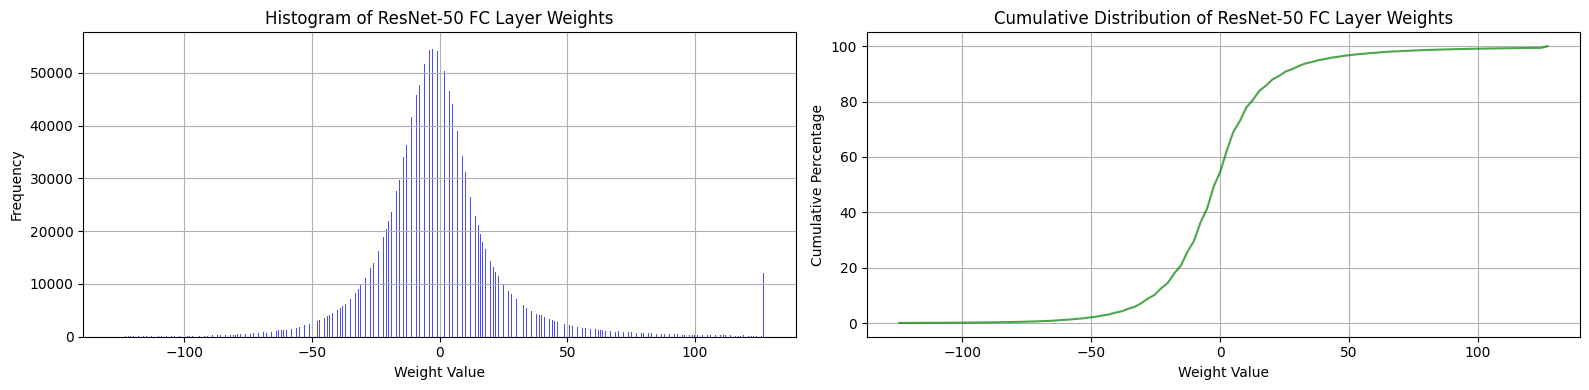

In [41]:
plot_weights_distribution(fc_weights_round_clip_int8)

> Note: You can see the effect of clipping in the jump in the right hand side of the X axis.

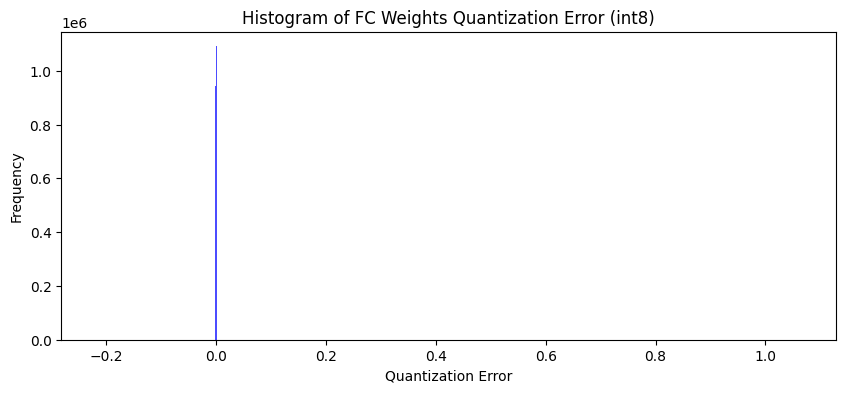

In [42]:
fc_weights_error_clip_int8 = fc_weights_flat - fc_weights_round_clip_int8 / scale_sym_clip_int8
plot_quant_error(fc_weights_error_clip_int8, str(fc_weights_round_clip_int8.dtype))

The majority of the quantization error is concentrated around zero, we can zoom in this region by using the clip function again.

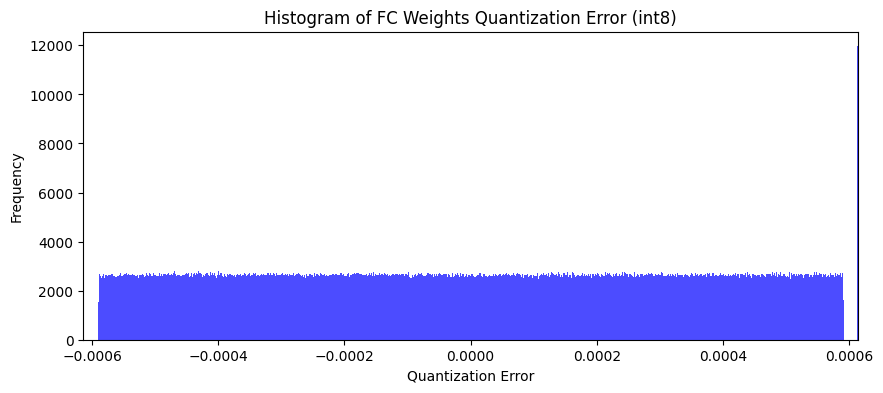

In [43]:
plot_quant_error(np.clip(fc_weights_error_clip_int8, -0.52/scale_sym_clip_int8, 0.52/scale_sym_clip_int8), str(fc_weights_round_clip_int8.dtype))

You can note that the MSE is still small, however, the RSS is really large.

In [44]:
int8_clip_sym_mse, int8_clip_sym_rss = quantization_error_stats(fc_weights_flat, fc_weights_scale_sym_clip_int8/scale_sym_clip_int8)
print(f'Symmetric clip INT8 Quant MSE: {int8_clip_sym_mse}, RSS: {int8_clip_sym_rss}')

Symmetric clip INT8 Quant MSE: 0.00046022195601835847, RSS: 942.5345458984375


## Comparing Statistics

Now, let's compare the statistics of the different quantization methods we saw.

In [45]:
from tabulate import tabulate

rows = [
    ["INT8 Symmetric",      int8_sym_mse,    int8_sym_rss],
    ["Bfloat16 Symmetric",  bf16_sym_mse,    bf16_sym_rss],
    ["INT8 Asymmetric",     int8_asym_mse,   int8_asym_rss],
    ["INT8 Symmetric Clip", int8_clip_sym_mse, int8_clip_sym_rss],
]

headers = ["Method", "MSE", "RSS"]
table = tabulate(rows, headers=headers, floatfmt=(".3g", ".3g", ".5g"), tablefmt="github")

print(table)

| Method              |      MSE |         RSS |
|---------------------|----------|-------------|
| INT8 Symmetric      | 8.59e-06 |  17.586     |
| Bfloat16 Symmetric  | 4.54e-09 |   0.0092882 |
| INT8 Asymmetric     | 3.75e-06 |   7.6891    |
| INT8 Symmetric Clip | 0.00046  | 942.53      |


> Note: Considering the 3 types of integer quantization we explored, the asymmetric quantization gives the best results, lowest MSE and RSS.

## References

<div class="alert alert-block alert-info">
<ul>
  <li><a href="https://huggingface.co/docs/optimum/en/concept_guides/quantization">Quantization</a></li>
</ul>
</div>

## Conclusions

We have seen different methods to quantize weights. We can do this offline because the range of the weights is known once the model is pre-trained. This is not the case for the activations. The range that the activations can take depends on the input to the model and hence other considerations are needed.

---

[AMD University Program](https://www.amd.com/aup).

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved.

SPDX-License-Identifier: MIT